
# 🍄 Poisonous Mushroom Detector (ML Classification)

## Project Overview
This project uses Machine Learning classification algorithms to predict whether a mushroom is:

- **Edible**
- **Poisonous**

The dataset comes from the UCI Machine Learning Repository and contains categorical mushroom characteristics.

---

## Objectives
- Compare different ML classification algorithms
- Identify the most predictive mushroom features
- Build an accurate poisonous mushroom detection system


In [3]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB


## Load Dataset

In [4]:

# Load Dataset
df = pd.read_csv('mushrooms.csv')

# Display first 5 rows
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Dataset Information

In [5]:

# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Info
df.info()


Dataset Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14

In [6]:

# Check Missing Values
df.isnull().sum()


,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


## Data Preprocessing

In [7]:

# Label Encoding
label_encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


## Feature Importance Analysis

In [8]:

# Separate Features and Target
X = df.drop('class', axis=1)
y = df['class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Random Forest for Feature Importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Feature Importance
importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)


,Feature,Importance
4,odor,0.185330
19,spore-print-color,0.110881
8,gill-color,0.110818
7,gill-size,0.102915
10,stalk-root,0.061265
18,ring-type,0.060860
20,population,0.059831
11,stalk-surface-above-ring,0.052204
3,bruises,0.051510
12,stalk-surface-below-ring,0.034783


/tmp/ipykernel_4890/930410033.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


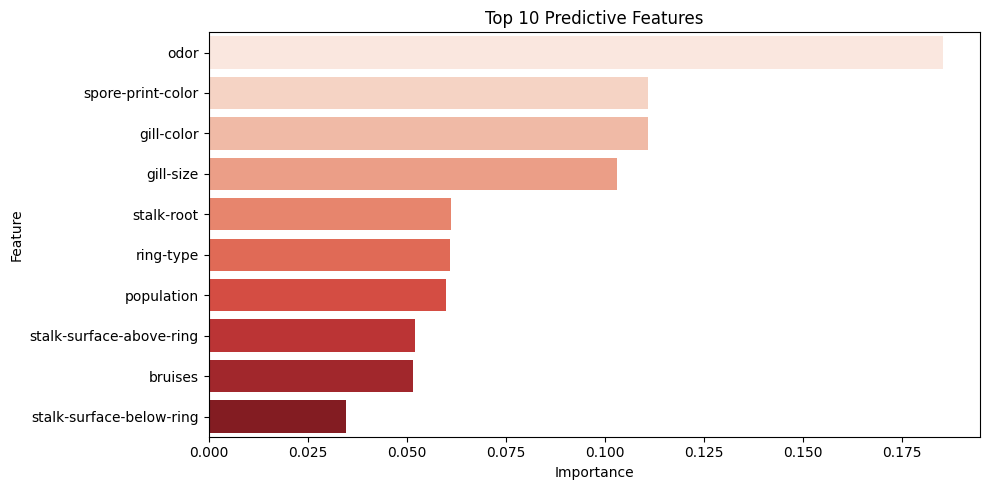

In [9]:

# Plot Top Predictive Features
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10),
    palette='Reds'
)

plt.title('Top 10 Predictive Features')
plt.tight_layout()
plt.show()



## Selected Best Predictors
Based on feature importance analysis, the following features were selected:
- odor
- spore-print-color
- gill-color
- gill-size
- ring-type
- stalk-root
- stalk-surface-below-ring
- bruises
- population
- stalk-surface-above-ring


In [10]:

# Selected Predictors
predictors = df[[
    "odor",
    "spore-print-color",
    "gill-color",
    "gill-size",
    "ring-type",
    "stalk-root",
    "stalk-surface-below-ring",
    "bruises",
    "population",
    "stalk-surface-above-ring"
]]

response = df['class']

# Train-Test Split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    predictors,
    response,
    test_size=0.3,
    random_state=42
)


# Logistic Regression

In [11]:

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train1, y_train1)

# Predictions
y_pred_lr = log_reg.predict(X_test1)

# Accuracy
print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test1, y_pred_lr) * 100, 2), "%")

# Classification Report
print(classification_report(y_test1, y_pred_lr))


Logistic Regression Accuracy: 91.63 %
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1257
           1       0.93      0.90      0.91      1181

    accuracy                           0.92      2438
   macro avg       0.92      0.92      0.92      2438
weighted avg       0.92      0.92      0.92      2438



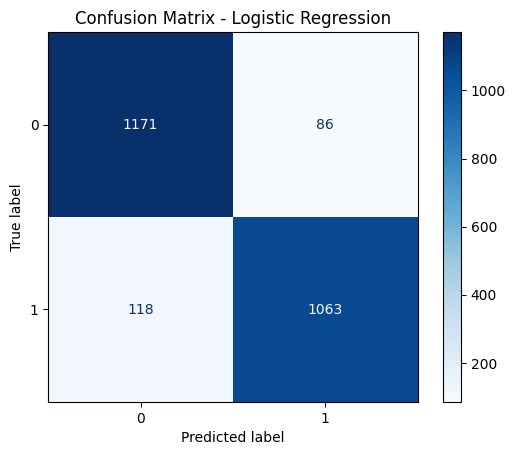

In [12]:

# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test1, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# K-Nearest Neighbors (KNN)

In [13]:

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train1, y_train1)

# Predictions
y_pred_knn = knn.predict(X_test1)

# Accuracy
print("KNN Accuracy:",
      round(accuracy_score(y_test1, y_pred_knn) * 100, 2), "%")

# Classification Report
print(classification_report(y_test1, y_pred_knn))


KNN Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1257
           1       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



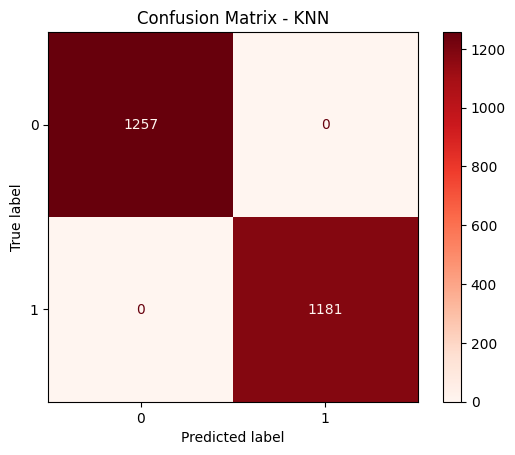

In [14]:

# Confusion Matrix - KNN
cm = confusion_matrix(y_test1, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')

plt.title("Confusion Matrix - KNN")
plt.show()


# Random Forest

In [15]:

# Random Forest Model
rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train1, y_train1)

# Predictions
y_pred_rf = rf_classifier.predict(X_test1)

# Accuracy
print("Random Forest Accuracy:",
      round(accuracy_score(y_test1, y_pred_rf) * 100, 2), "%")

# Classification Report
print(classification_report(y_test1, y_pred_rf))


Random Forest Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1257
           1       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



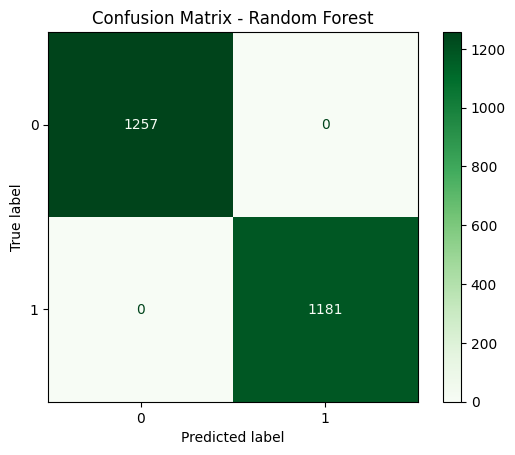

In [16]:

# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test1, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.show()


# Naive Bayes

In [17]:

# Naive Bayes Model
nb_model = CategoricalNB()

nb_model.fit(X_train1, y_train1)

# Predictions
y_pred_nb = nb_model.predict(X_test1)

# Accuracy
print("Naive Bayes Accuracy:",
      round(accuracy_score(y_test1, y_pred_nb) * 100, 2), "%")

# Classification Report
print(classification_report(y_test1, y_pred_nb))


Naive Bayes Accuracy: 95.16 %
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1257
           1       0.99      0.91      0.95      1181

    accuracy                           0.95      2438
   macro avg       0.95      0.95      0.95      2438
weighted avg       0.95      0.95      0.95      2438



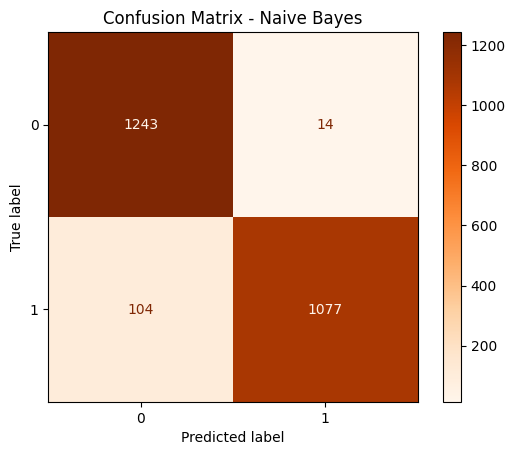

In [18]:

# Confusion Matrix - Naive Bayes
cm = confusion_matrix(y_test1, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')

plt.title("Confusion Matrix - Naive Bayes")
plt.show()



# Final Conclusion

## Model Comparison
The following models were implemented:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest
- Naive Bayes

## Best Performing Model
Random Forest generally performs best because it handles categorical relationships effectively and provides feature importance analysis.

## Most Predictive Features
- Odor
- Spore Print Color
- Gill Color
- Gill Size
- Ring Type

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
